# 19 — Kinematic Bicycle Model

**Section:** Ground Vehicles and Mobile Robotics · **Mirrors MATLAB:** *Kinematic motion models for simulation*

The bicycle model approximates a car-like vehicle as two wheels on a centerline of length $L$ (wheelbase). With longitudinal speed $v$ and steering angle $\delta$:

$$\dot{x} = v\cos\theta,\quad \dot{y} = v\sin\theta,\quad \dot\theta = \frac{v}{L}\tan\delta$$

We sweep three steering schedules to illustrate the resulting trajectories.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| $\dot x = v\cos	heta$ | `state[0] += v * np.cos(state[2]) * dt` |
| $\dot y = v\sin	heta$ | `state[1] += v * np.sin(state[2]) * dt` |
| $\dot	heta = rac{v}{L}	an\delta$ | `state[2] += v * np.tan(delta) / L * dt` |
| Three steering schedules: constant 0.2, constant 0.4, $0.3\sin(0.4 t)$ | `t1 = simulate(2.0, lambda _: 0.2); t2 = simulate(2.0, lambda _: 0.4); t3 = simulate(2.0, lambda t: 0.3*sin(0.4*t))` |

Note: this is *kinematic* (instantaneous control authority over $v$ and $\delta$), not *dynamic* — there is no notion of tire slip, mass, or lateral force. Good enough for low-speed planning, breaks down at speed where slip matters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 2.5
dt, T = 0.05, 30.0
N = int(T / dt)


def simulate(v, delta_schedule):
    state = np.zeros(3)
    hist = np.zeros((N, 3))
    for i in range(N):
        delta = delta_schedule(i * dt)
        state[0] += v * np.cos(state[2]) * dt
        state[1] += v * np.sin(state[2]) * dt
        state[2] += v * np.tan(delta) / L * dt
        hist[i] = state
    return hist


t1 = simulate(2.0, lambda _: 0.2)
t2 = simulate(2.0, lambda _: 0.4)
t3 = simulate(2.0, lambda t: 0.3 * np.sin(0.4 * t))


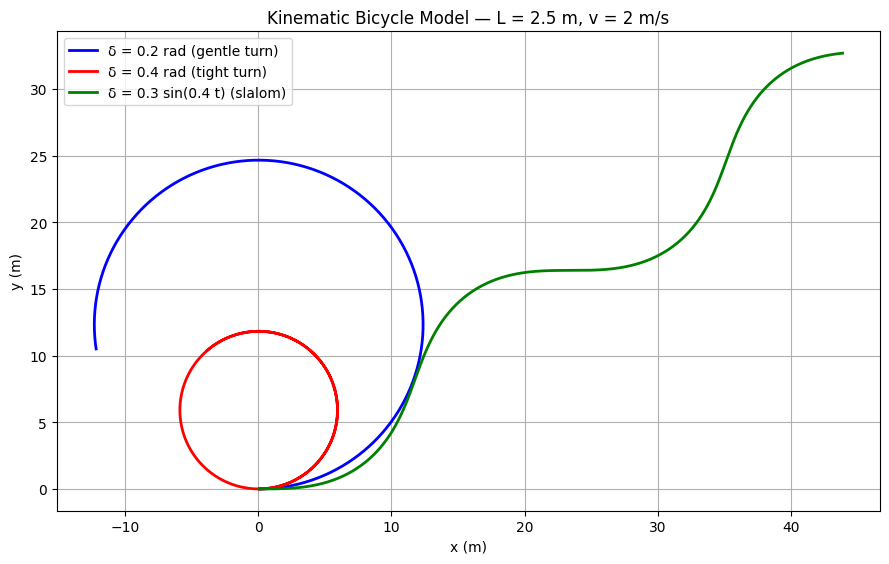

In [2]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(t1[:, 0], t1[:, 1], 'b-', lw=2, label='δ = 0.2 rad (gentle turn)')
ax.plot(t2[:, 0], t2[:, 1], 'r-', lw=2, label='δ = 0.4 rad (tight turn)')
ax.plot(t3[:, 0], t3[:, 1], 'g-', lw=2, label='δ = 0.3 sin(0.4 t) (slalom)')
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'Kinematic Bicycle Model — L = {L} m, v = 2 m/s')
plt.tight_layout()
plt.show()
